# Small-molecule targeting of kinesin-13 KIF2C enhances double-strand break DNA repair and slows down aging

## RNA-seq Analysis in Python

Below, I will perform RNA-seq (IonTorrent Targeted Transcriptome) analysis on HGPS fibroblasts treated with UMK57, thus reproducing in Python the analysis made in the Nature Communications paper "Small-molecule targeting of kinesin-13 KIF2C enhances double-strand break DNA repair and slows down aging".

### Check Working Directory

In [80]:
import os

In [81]:
os.getcwd()

'C:\\Users\\cdsou\\Desktop\\Bioinformatics\\Python\\hgps_ds_umk57_practise'

### Import RNA-seq Data

Raw gene counts were obtained from the IonTorrent suite. Counts and metadata are available in the original repository for the paper:

In [82]:
import pandas as pd
import numpy as np
pd.__version__

'2.3.3'

In [83]:
np.__version__

'2.3.5'

In [84]:
raw_counts = pd.read_csv("input_data/counts_matrix.csv", sep = ",", index_col = 0)
raw_counts

,IonXpress_013_03042019,IonXpress_014_03042019,IonXpress_007_21012022,IonXpress_014_21012022,IonXpress_005_27012022,IonXpress_006_27012022,IonXpress_013_27012022,IonXpress_014_27012022,IonXpress_007_03042019,IonXpress_008_03042019,IonXpress_092_22082022,IonXpress_096_22082022,IonXpress_090_22082022,IonXpress_094_22082022,IonXpress_091_22082022,IonXpress_095_22082022,IonXpress_089_22082022,IonXpress_093_22082022
SEC24B-AS1,1,1,5,0,2,2,2,1,9,1,6,5,1,1,6,4,4,4
A1BG,5,2,0,0,2,1,4,3,0,1,3,1,2,3,6,1,2,1
A1CF,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
GGACT,3,2,0,0,3,1,0,4,1,2,2,0,0,2,2,1,1,0
A2M,161,28,64,18,387,62,303,51,3,2,3,17,27,41,59,35,75,51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ERCC-00112,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ERCC-00131,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ERCC-00136,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
ERCC-00157,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [85]:
sample_metadata = pd.read_csv("input_data/sample_info.csv", sep = ",", index_col = 0)
sample_metadata

,Individual,Treatment,Disease,batch,X,geo_sample,Exp_Batch_Correct
IonXpress_013_03042019,HGPS 169,DMSO,HGPS,3042019,IonXpress_013_03042019,HGPS 169_DMSO_1,A
IonXpress_014_03042019,HGPS 169,UMK57,HGPS,3042019,IonXpress_014_03042019,HGPS 169_UMK57_1,A
IonXpress_007_21012022,HGPS 169,DMSO,HGPS,21012022,IonXpress_007_21012022,HGPS 169_DMSO_2,B
IonXpress_014_21012022,HGPS 169,UMK57,HGPS,21012022,IonXpress_014_21012022,HGPS 169_UMK57_2,B
IonXpress_005_27012022,HGPS 169,DMSO,HGPS,27012022,IonXpress_005_27012022,HGPS 169_DMSO_3,C
IonXpress_006_27012022,HGPS 169,UMK57,HGPS,27012022,IonXpress_006_27012022,HGPS 169_UMK57_3,C
IonXpress_013_27012022,HGPS 169,DMSO,HGPS,27012022,IonXpress_013_27012022,HGPS 169_DMSO_4,C
IonXpress_014_27012022,HGPS 169,UMK57,HGPS,27012022,IonXpress_014_27012022,HGPS 169_UMK57_4,C
IonXpress_007_03042019,NEO,DMSO,Healthy,3042019,IonXpress_007_03042019,NEO_DMSO_1,A
IonXpress_008_03042019,NEO,DMSO,Healthy,3042019,IonXpress_008_03042019,NEO_DMSO_2,A


Counts matrices need to show samples in rows, so we need to transpose:

In [86]:
raw_counts_trans = raw_counts.T
raw_counts_trans

,SEC24B-AS1,A1BG,A1CF,GGACT,A2M,A2ML1,A2MP1,A4GALT,A4GNT,AAAS,...,ERCC-00031,ERCC-00042,ERCC-00069,ERCC-00084,ERCC-00097,ERCC-00112,ERCC-00131,ERCC-00136,ERCC-00157,ERCC-00171
IonXpress_013_03042019,1,5,0,3,161,0,0,490,0,276,...,0,0,0,0,0,0,0,0,0,0
IonXpress_014_03042019,1,2,0,2,28,0,0,259,0,299,...,0,0,0,0,0,0,0,0,0,0
IonXpress_007_21012022,5,0,0,0,64,0,0,249,0,209,...,0,0,0,0,0,0,0,0,0,0
IonXpress_014_21012022,0,0,0,0,18,0,0,122,0,144,...,0,0,0,0,0,0,0,0,0,0
IonXpress_005_27012022,2,2,0,3,387,0,0,864,0,501,...,0,0,0,0,0,0,0,0,0,0
IonXpress_006_27012022,2,1,0,1,62,0,0,713,0,681,...,0,0,0,0,0,0,0,0,0,0
IonXpress_013_27012022,2,4,0,0,303,0,0,614,0,470,...,0,0,0,0,0,0,0,0,0,0
IonXpress_014_27012022,1,3,0,4,51,0,0,412,0,568,...,0,0,0,0,0,0,0,0,0,0
IonXpress_007_03042019,9,0,0,1,3,0,0,220,0,591,...,0,0,0,0,0,0,0,0,0,0
IonXpress_008_03042019,1,1,0,2,2,0,0,271,0,598,...,0,0,0,0,0,0,0,0,0,0


Check if sample names match between counts matrix and metadata:

In [87]:
raw_counts_trans.index == sample_metadata.index

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

#### HGPS UMK57 vs DMSO

Raw counts are available for Young, HGPS and Down Syndrome fibroblasts. First, I will select only samples of interest (HGPS):

In [88]:
samples_of_interest = "HGPS"
samples_of_interest

'HGPS'

In [89]:
sample_metadata["Disease"] == samples_of_interest

IonXpress_013_03042019     True
IonXpress_014_03042019     True
IonXpress_007_21012022     True
IonXpress_014_21012022     True
IonXpress_005_27012022     True
IonXpress_006_27012022     True
IonXpress_013_27012022     True
IonXpress_014_27012022     True
IonXpress_007_03042019    False
IonXpress_008_03042019    False
IonXpress_092_22082022    False
IonXpress_096_22082022    False
IonXpress_090_22082022    False
IonXpress_094_22082022    False
IonXpress_091_22082022    False
IonXpress_095_22082022    False
IonXpress_089_22082022    False
IonXpress_093_22082022    False
Name: Disease, dtype: bool

In [90]:
hgps_samples = sample_metadata.loc[sample_metadata["Disease"] == samples_of_interest]
hgps_samples

,Individual,Treatment,Disease,batch,X,geo_sample,Exp_Batch_Correct
IonXpress_013_03042019,HGPS 169,DMSO,HGPS,3042019,IonXpress_013_03042019,HGPS 169_DMSO_1,A
IonXpress_014_03042019,HGPS 169,UMK57,HGPS,3042019,IonXpress_014_03042019,HGPS 169_UMK57_1,A
IonXpress_007_21012022,HGPS 169,DMSO,HGPS,21012022,IonXpress_007_21012022,HGPS 169_DMSO_2,B
IonXpress_014_21012022,HGPS 169,UMK57,HGPS,21012022,IonXpress_014_21012022,HGPS 169_UMK57_2,B
IonXpress_005_27012022,HGPS 169,DMSO,HGPS,27012022,IonXpress_005_27012022,HGPS 169_DMSO_3,C
IonXpress_006_27012022,HGPS 169,UMK57,HGPS,27012022,IonXpress_006_27012022,HGPS 169_UMK57_3,C
IonXpress_013_27012022,HGPS 169,DMSO,HGPS,27012022,IonXpress_013_27012022,HGPS 169_DMSO_4,C
IonXpress_014_27012022,HGPS 169,UMK57,HGPS,27012022,IonXpress_014_27012022,HGPS 169_UMK57_4,C


In [91]:
hgps_samples.index

Index(['IonXpress_013_03042019', 'IonXpress_014_03042019',
       'IonXpress_007_21012022', 'IonXpress_014_21012022',
       'IonXpress_005_27012022', 'IonXpress_006_27012022',
       'IonXpress_013_27012022', 'IonXpress_014_27012022'],
      dtype='object')

In [92]:
raw_counts_trans.index.isin(hgps_samples.index)

array([ True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False, False, False, False, False, False, False, False])

In [93]:
raw_counts_hgps = raw_counts_trans.loc[raw_counts_trans.index.isin(hgps_samples.index)]
raw_counts_hgps

,SEC24B-AS1,A1BG,A1CF,GGACT,A2M,A2ML1,A2MP1,A4GALT,A4GNT,AAAS,...,ERCC-00031,ERCC-00042,ERCC-00069,ERCC-00084,ERCC-00097,ERCC-00112,ERCC-00131,ERCC-00136,ERCC-00157,ERCC-00171
IonXpress_013_03042019,1,5,0,3,161,0,0,490,0,276,...,0,0,0,0,0,0,0,0,0,0
IonXpress_014_03042019,1,2,0,2,28,0,0,259,0,299,...,0,0,0,0,0,0,0,0,0,0
IonXpress_007_21012022,5,0,0,0,64,0,0,249,0,209,...,0,0,0,0,0,0,0,0,0,0
IonXpress_014_21012022,0,0,0,0,18,0,0,122,0,144,...,0,0,0,0,0,0,0,0,0,0
IonXpress_005_27012022,2,2,0,3,387,0,0,864,0,501,...,0,0,0,0,0,0,0,0,0,0
IonXpress_006_27012022,2,1,0,1,62,0,0,713,0,681,...,0,0,0,0,0,0,0,0,0,0
IonXpress_013_27012022,2,4,0,0,303,0,0,614,0,470,...,0,0,0,0,0,0,0,0,0,0
IonXpress_014_27012022,1,3,0,4,51,0,0,412,0,568,...,0,0,0,0,0,0,0,0,0,0


In [94]:
raw_counts_hgps.index == hgps_samples.index

array([ True,  True,  True,  True,  True,  True,  True,  True])

#### Gene Filtering for DESeq2

Here, I will filter genes that have very low expression as recommended for DESeq2 analysis:

In [95]:
min_count = 5

In [96]:
(raw_counts_hgps > min_count).sum()

SEC24B-AS1    0
A1BG          0
A1CF          0
GGACT         0
A2M           8
             ..
ERCC-00112    0
ERCC-00131    0
ERCC-00136    0
ERCC-00157    0
ERCC-00171    0
Length: 20812, dtype: int64

So, for each gene, this shows how many samples have a min. count of 5. Let's filter then:

In [97]:
genes_to_keep = (raw_counts_hgps > min_count).sum() >= (len(raw_counts_hgps)/2) 
genes_to_keep

SEC24B-AS1    False
A1BG          False
A1CF          False
GGACT         False
A2M            True
              ...  
ERCC-00112    False
ERCC-00131    False
ERCC-00136    False
ERCC-00157    False
ERCC-00171    False
Length: 20812, dtype: bool

In [98]:
raw_counts_hgps_filt = raw_counts_hgps.loc[:, genes_to_keep]
raw_counts_hgps_filt

,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,AAMP,AARS,AARS2,...,ZNF564,ZNF595,ZNF720,ZNF763,ZNF776,ZNF788,ZNF826P,HYDIN,RNF213,SFMBT1
IonXpress_013_03042019,161,490,276,69,25,331,42,556,2102,58,...,30,33,18,10,61,28,4,8,346,27
IonXpress_014_03042019,28,259,299,113,36,317,33,429,1743,62,...,19,24,14,13,68,35,0,3,231,14
IonXpress_007_21012022,64,249,209,102,36,361,16,471,1146,23,...,14,27,35,21,82,36,1,10,359,18
IonXpress_014_21012022,18,122,144,73,20,294,12,220,663,39,...,8,31,26,2,68,22,12,7,104,9
IonXpress_005_27012022,387,864,501,178,56,705,66,1288,3255,93,...,41,71,48,31,179,71,6,19,854,45
IonXpress_006_27012022,62,713,681,206,60,824,78,1408,3002,110,...,46,61,76,27,202,65,6,3,736,49
IonXpress_013_27012022,303,614,470,173,53,800,69,1013,3421,52,...,57,62,76,36,142,67,7,25,569,52
IonXpress_014_27012022,51,412,568,240,75,780,59,949,2792,77,...,51,63,69,13,190,80,6,6,485,33


#### DESeq2 HGPS

Next, we will run DESeq2 on HGPS UMK57 vs DMSO samples:

In [99]:
import pickle as pkl
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

In [100]:
inference = DefaultInference(n_cpus=8)
dds_HGPS = DeseqDataSet(
    counts = raw_counts_hgps_filt,
    metadata = hgps_samples,
    design = "~Treatment",
    refit_cooks = True,
    inference = inference,
)

In [101]:
dds_HGPS.deseq2()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.30 seconds.

Fitting dispersion trend curve...
... done in 0.27 seconds.

Fitting MAP dispersions...
... done in 2.52 seconds.

Fitting LFCs...
... done in 1.65 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [102]:
deseq2_results_hgps = DeseqStats(dds_HGPS, contrast = ["Treatment", "UMK57", "DMSO"], inference = inference, cooks_filter = False, independent_filter = False)

In [103]:
deseq2_results_hgps.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Treatment UMK57 vs DMSO
           baseMean  log2FoldChange     lfcSE      stat        pvalue  \
A2M      110.647314       -2.300608  0.291172 -7.901186  2.762611e-15   
A4GALT   406.186426       -0.511991  0.202303 -2.530813  1.137984e-02   
AAAS     351.174682        0.279100  0.140804  1.982190  4.745797e-02   
AACS     134.881456        0.410881  0.235557  1.744294  8.110787e-02   
AADAT     42.313151        0.258665  0.295235  0.876132  3.809584e-01   
...             ...             ...       ...       ...           ...   
ZNF788    46.327610        0.119647  0.275666  0.434027  6.642689e-01   
ZNF826P    6.572099        1.134823  0.904715  1.254343  2.097175e-01   
HYDIN     10.083200       -1.284100  0.631022 -2.034952  4.185575e-02   
RNF213   397.520101       -0.485771  0.192751 -2.520200  1.172882e-02   
SFMBT1    26.729863       -0.397466  0.317053 -1.253629  2.099768e-01   

                 padj  
A2M      1.562633e-12  
A4GALT   1.32

... done in 0.97 seconds.



In [104]:
deseq2_results_hgps.results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A2M,110.647314,-2.300608,0.291172,-7.901186,2.762611e-15,1.562633e-12
A4GALT,406.186426,-0.511991,0.202303,-2.530813,1.137984e-02,1.324702e-01
AAAS,351.174682,0.279100,0.140804,1.982190,4.745797e-02,3.165673e-01
AACS,134.881456,0.410881,0.235557,1.744294,8.110787e-02,4.135776e-01
AADAT,42.313151,0.258665,0.295235,0.876132,3.809584e-01,7.899760e-01
...,...,...,...,...,...,...
ZNF788,46.327610,0.119647,0.275666,0.434027,6.642689e-01,9.177894e-01
ZNF826P,6.572099,1.134823,0.904715,1.254343,2.097175e-01,6.402249e-01
HYDIN,10.083200,-1.284100,0.631022,-2.034952,4.185575e-02,2.967823e-01
RNF213,397.520101,-0.485771,0.192751,-2.520200,1.172882e-02,1.352878e-01


In [105]:
deseq2_results_hgps.results_df.to_csv("output_data/deseq2_results_hgps.csv")

Let's create a volcano plot with the results. I will use the Let's Plot library, which has a similar syntax to ggplot:

In [106]:
from lets_plot import *
LetsPlot.setup_html()

In [107]:
deseq2_results_hgps_df = deseq2_results_hgps.results_df
deseq2_results_hgps_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A2M,110.647314,-2.300608,0.291172,-7.901186,2.762611e-15,1.562633e-12
A4GALT,406.186426,-0.511991,0.202303,-2.530813,1.137984e-02,1.324702e-01
AAAS,351.174682,0.279100,0.140804,1.982190,4.745797e-02,3.165673e-01
AACS,134.881456,0.410881,0.235557,1.744294,8.110787e-02,4.135776e-01
AADAT,42.313151,0.258665,0.295235,0.876132,3.809584e-01,7.899760e-01
...,...,...,...,...,...,...
ZNF788,46.327610,0.119647,0.275666,0.434027,6.642689e-01,9.177894e-01
ZNF826P,6.572099,1.134823,0.904715,1.254343,2.097175e-01,6.402249e-01
HYDIN,10.083200,-1.284100,0.631022,-2.034952,4.185575e-02,2.967823e-01
RNF213,397.520101,-0.485771,0.192751,-2.520200,1.172882e-02,1.352878e-01


In [108]:
deseq2_results_hgps_df["log10padj"] = -np.log10(deseq2_results_hgps_df["padj"])
deseq2_results_hgps_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,log10padj
A2M,110.647314,-2.300608,0.291172,-7.901186,2.762611e-15,1.562633e-12,11.806143
A4GALT,406.186426,-0.511991,0.202303,-2.530813,1.137984e-02,1.324702e-01,0.877882
AAAS,351.174682,0.279100,0.140804,1.982190,4.745797e-02,3.165673e-01,0.499534
AACS,134.881456,0.410881,0.235557,1.744294,8.110787e-02,4.135776e-01,0.383443
AADAT,42.313151,0.258665,0.295235,0.876132,3.809584e-01,7.899760e-01,0.102386
...,...,...,...,...,...,...,...
ZNF788,46.327610,0.119647,0.275666,0.434027,6.642689e-01,9.177894e-01,0.037257
ZNF826P,6.572099,1.134823,0.904715,1.254343,2.097175e-01,6.402249e-01,0.193667
HYDIN,10.083200,-1.284100,0.631022,-2.034952,4.185575e-02,2.967823e-01,0.527562
RNF213,397.520101,-0.485771,0.192751,-2.520200,1.172882e-02,1.352878e-01,0.868741


In [109]:
deseq2_results_hgps_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,log10padj
A2M,110.647314,-2.300608,0.291172,-7.901186,2.762611e-15,1.562633e-12,11.806143
A4GALT,406.186426,-0.511991,0.202303,-2.530813,1.137984e-02,1.324702e-01,0.877882
AAAS,351.174682,0.279100,0.140804,1.982190,4.745797e-02,3.165673e-01,0.499534
AACS,134.881456,0.410881,0.235557,1.744294,8.110787e-02,4.135776e-01,0.383443
AADAT,42.313151,0.258665,0.295235,0.876132,3.809584e-01,7.899760e-01,0.102386
...,...,...,...,...,...,...,...
ZNF788,46.327610,0.119647,0.275666,0.434027,6.642689e-01,9.177894e-01,0.037257
ZNF826P,6.572099,1.134823,0.904715,1.254343,2.097175e-01,6.402249e-01,0.193667
HYDIN,10.083200,-1.284100,0.631022,-2.034952,4.185575e-02,2.967823e-01,0.527562
RNF213,397.520101,-0.485771,0.192751,-2.520200,1.172882e-02,1.352878e-01,0.868741


In [111]:
conditions = [
    (deseq2_results_hgps_df['padj'] < 0.05) & (deseq2_results_hgps_df['log2FoldChange'] > 0),
    (deseq2_results_hgps_df['padj'] < 0.05) & (deseq2_results_hgps_df['log2FoldChange'] < 0)
]
choices = ['Up', 'Down']

deseq2_results_hgps_df['change'] = np.select(conditions, choices, default='No Change')
deseq2_results_hgps_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,log10padj,change
A2M,110.647314,-2.300608,0.291172,-7.901186,2.762611e-15,1.562633e-12,11.806143,Down
A4GALT,406.186426,-0.511991,0.202303,-2.530813,1.137984e-02,1.324702e-01,0.877882,No Change
AAAS,351.174682,0.279100,0.140804,1.982190,4.745797e-02,3.165673e-01,0.499534,No Change
AACS,134.881456,0.410881,0.235557,1.744294,8.110787e-02,4.135776e-01,0.383443,No Change
AADAT,42.313151,0.258665,0.295235,0.876132,3.809584e-01,7.899760e-01,0.102386,No Change
...,...,...,...,...,...,...,...,...
ZNF788,46.327610,0.119647,0.275666,0.434027,6.642689e-01,9.177894e-01,0.037257,No Change
ZNF826P,6.572099,1.134823,0.904715,1.254343,2.097175e-01,6.402249e-01,0.193667,No Change
HYDIN,10.083200,-1.284100,0.631022,-2.034952,4.185575e-02,2.967823e-01,0.527562,No Change
RNF213,397.520101,-0.485771,0.192751,-2.520200,1.172882e-02,1.352878e-01,0.868741,No Change


In [112]:
ggplot(deseq2_results_hgps_df, aes(x = "log2FoldChange", y = "log10padj")) + \
geom_point(aes(color = "change"), size = 1.5, alpha = 0.5) + \
scale_color_manual(values = ['blue', 'gray', 'red'], name = "Direction") + \
labs(x = "Log2FC", y = "-log10(padjust)") + \
theme_bw() + \
xlim(-6, 4) + \
geom_vline(xintercept = 0, linetype = "dotted") + \
geom_hline(yintercept = 1.301, linetype = "dotted")

As in the paper, we can see that several hundred genes become differentially expressed upon UMK57 treatment.

### GSEA Analysis

Here, I will do GSEA analysis using the Hallmark gene sets. I will use the GSEApy library:

In [113]:
import gseapy as gp

In [114]:
gp.__version__

'1.1.11'

In [115]:
hgps_ranked = deseq2_results_hgps_df.sort_values("log2FoldChange", ascending = False)
hgps_ranked

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,log10padj,change
PKP1,16.726248,2.432611,0.487084,4.994232,5.907036e-07,4.983034e-05,4.302506,Up
SLC6A15,8.071855,2.308497,0.712651,3.239310,1.198194e-03,2.593100e-02,1.586181,Up
EDARADD,10.125165,2.278140,0.628841,3.622761,2.914746e-04,8.534377e-03,2.068828,Up
MAATS1,7.197231,2.269787,0.686674,3.305478,9.481466e-04,2.145225e-02,1.668527,Up
LIPG,22.491942,2.126384,0.404121,5.261754,1.426877e-07,1.443582e-05,4.840558,Up
...,...,...,...,...,...,...,...,...
TNFSF15,36.054707,-3.969356,0.544554,-7.289194,3.118151e-13,9.023784e-11,10.044611,Down
DAB1,13.562133,-4.034040,0.671852,-6.004363,1.920850e-09,3.145139e-07,6.502360,Down
C3,5.434669,-5.023721,1.370420,-3.665827,2.465410e-04,7.519499e-03,2.123811,Down
PLA2G2A,8.818889,-5.089343,1.091151,-4.664197,3.098239e-06,2.029183e-04,3.692679,Down


In [116]:
hgps_ranked_2 = hgps_ranked["log2FoldChange"]
hgps_ranked_2.index

Index(['PKP1', 'SLC6A15', 'EDARADD', 'MAATS1', 'LIPG', 'GRB14', 'TLL2', 'BMP2',
       'PLEK2', 'LINC00161',
       ...
       'RSPH9', 'VTN', 'SNORA42', 'SNORA46', 'CCL13', 'TNFSF15', 'DAB1', 'C3',
       'PLA2G2A', 'SNORA53'],
      dtype='object', length=12444)

In [117]:
hgps_ranked_2.shape

(12444,)

In [118]:
HALLMARK_HGPS_UMK57 = gp.prerank(
    rnk = hgps_ranked_2,    
    gene_sets = "MSigDB_Hallmark_2020",
    method = "multilevel",            
    sample_size = 101,                
    eps = 1e-50,                     
    threads = 4,
    min_size = 5,
    max_size = 1000,
    seed = 6,
    outdir = None
)

In [119]:
df_HALLMARK_HGPS_UMK57 = HALLMARK_HGPS_UMK57.res2d
df_HALLMARK_HGPS_UMK57.head(10)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,E2F Targets,0.573487,2.611321,0.0,0.0,0.0,130/191,27.58%,AURKB;KIF4A;CDC25A;CENPE;LMNB1;GINS1;ORC6;AURK...
1,prerank,G2-M Checkpoint,0.530369,2.441196,0.0,0.0,0.0,87/186,18.08%,MT2A;CDC7;AURKB;CCNF;RAD54L;KIF4A;CDC25A;CENPE...
2,prerank,Interferon Gamma Response,-0.667943,-2.332702,0.0,0.0,0.0,73/148,14.88%,C1R;VCAM1;ICAM1;CASP1;C1S;SERPING1;SECTM1;IFIT...
3,prerank,Interferon Alpha Response,-0.723567,-2.321659,0.0,0.0,0.0,40/77,14.19%,CASP1;TMEM140;C1S;IFIT3;IFIT2;EPSTI1;PSMB9;BST...
4,prerank,Myc Targets V1,0.456086,2.107545,0.0,0.0,0.0,115/194,32.54%,PSMA6;MAD2L1;CDK2;USP1;NME1;CDC45;PSMA4;HNRNPA...
5,prerank,IL-6/JAK/STAT3 Signaling,-0.682969,-2.080344,0.0,0.000279,0.001,19/54,8.72%,PLA2G2A;A2M;IL1B;PIM1;CXCL1;IL1R1;MAP3K8;IL6;I...
6,prerank,Inflammatory Response,-0.576022,-1.958406,0.0,0.00021,0.001,38/109,9.72%,TNFSF15;BEST1;ICAM1;IL1B;ABCA1;CCL2;IL18;CXCL6...
7,prerank,Angiogenesis,-0.67382,-1.896963,0.0,0.000168,0.001,11/30,9.15%,VTN;SLCO2A1;CXCL6;COL3A1;POSTN;JAG2;LUM;JAG1;V...
8,prerank,Myc Targets V2,0.493308,1.831811,0.0,0.00273,0.006,35/57,29.15%,SLC19A1;DCTPP1;TCOF1;MCM5;SRM;PLK1;NOP2;RRP12;...
9,prerank,TNF-alpha Signaling via NF-kB,-0.513186,-1.814134,0.0,0.000698,0.005,53/164,8.93%,CXCL2;FOS;ICAM1;IL1B;ATF3;ABCA1;CXCL1;CCL2;IL1...


In [72]:
conditions = [
    (df_HALLMARK_HGPS_UMK57['FDR q-val'] < 0.05) & (df_HALLMARK_HGPS_UMK57['NES'] > 0),
    (df_HALLMARK_HGPS_UMK57['FDR q-val'] < 0.05) & (df_HALLMARK_HGPS_UMK57['NES'] < 0)
]
choices = ['Up', 'Down']

df_HALLMARK_HGPS_UMK57['change'] = np.select(conditions, choices, default='No Change')
df_HALLMARK_HGPS_UMK57.head(10)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,change
0,prerank,E2F Targets,0.573487,2.625863,0.0,0.0,0.0,130/191,27.58%,AURKB;KIF4A;CDC25A;CENPE;LMNB1;GINS1;ORC6;AURK...,Up
1,prerank,G2-M Checkpoint,0.530369,2.4851,0.0,0.0,0.0,87/186,18.08%,MT2A;CDC7;AURKB;CCNF;RAD54L;KIF4A;CDC25A;CENPE...,Up
2,prerank,Interferon Alpha Response,-0.723567,-2.321685,0.0,0.0,0.0,40/77,14.19%,CASP1;TMEM140;C1S;IFIT3;IFIT2;EPSTI1;PSMB9;BST...,Down
3,prerank,Interferon Gamma Response,-0.667943,-2.321504,0.0,0.0,0.0,73/148,14.88%,C1R;VCAM1;ICAM1;CASP1;C1S;SERPING1;SECTM1;IFIT...,Down
4,prerank,IL-6/JAK/STAT3 Signaling,-0.682969,-2.129857,0.0,0.0,0.0,19/54,8.72%,PLA2G2A;A2M;IL1B;PIM1;CXCL1;IL1R1;MAP3K8;IL6;I...,Down
5,prerank,Myc Targets V1,0.456086,2.070217,0.0,0.0,0.0,115/194,32.54%,PSMA6;MAD2L1;CDK2;USP1;NME1;CDC45;PSMA4;HNRNPA...,Up
6,prerank,Inflammatory Response,-0.576022,-1.963942,0.0,0.00021,0.001,38/109,9.72%,TNFSF15;BEST1;ICAM1;IL1B;ABCA1;CCL2;IL18;CXCL6...,Down
7,prerank,Angiogenesis,-0.67382,-1.858903,0.0,0.001173,0.007,11/30,9.15%,VTN;SLCO2A1;CXCL6;COL3A1;POSTN;JAG2;LUM;JAG1;V...,Down
8,prerank,Myc Targets V2,0.493308,1.835113,0.0,0.002274,0.005,35/57,29.15%,SLC19A1;DCTPP1;TCOF1;MCM5;SRM;PLK1;NOP2;RRP12;...,Up
9,prerank,TNF-alpha Signaling via NF-kB,-0.513186,-1.82559,0.0,0.001257,0.009,53/164,8.93%,CXCL2;FOS;ICAM1;IL1B;ATF3;ABCA1;CXCL1;CCL2;IL1...,Down


In [73]:
df_HALLMARK_HGPS_UMK57_signif = df_HALLMARK_HGPS_UMK57.loc[df_HALLMARK_HGPS_UMK57["change"].isin(["Up", "Down"])]

In [74]:
df_HALLMARK_HGPS_UMK57_signif = df_HALLMARK_HGPS_UMK57_signif.sort_values("NES", ascending=True)
df_HALLMARK_HGPS_UMK57_signif

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,change
2,prerank,Interferon Alpha Response,-0.723567,-2.321685,0.0,0.0,0.0,40/77,14.19%,CASP1;TMEM140;C1S;IFIT3;IFIT2;EPSTI1;PSMB9;BST...,Down
3,prerank,Interferon Gamma Response,-0.667943,-2.321504,0.0,0.0,0.0,73/148,14.88%,C1R;VCAM1;ICAM1;CASP1;C1S;SERPING1;SECTM1;IFIT...,Down
4,prerank,IL-6/JAK/STAT3 Signaling,-0.682969,-2.129857,0.0,0.0,0.0,19/54,8.72%,PLA2G2A;A2M;IL1B;PIM1;CXCL1;IL1R1;MAP3K8;IL6;I...,Down
6,prerank,Inflammatory Response,-0.576022,-1.963942,0.0,0.00021,0.001,38/109,9.72%,TNFSF15;BEST1;ICAM1;IL1B;ABCA1;CCL2;IL18;CXCL6...,Down
7,prerank,Angiogenesis,-0.67382,-1.858903,0.0,0.001173,0.007,11/30,9.15%,VTN;SLCO2A1;CXCL6;COL3A1;POSTN;JAG2;LUM;JAG1;V...,Down
9,prerank,TNF-alpha Signaling via NF-kB,-0.513186,-1.82559,0.0,0.001257,0.009,53/164,8.93%,CXCL2;FOS;ICAM1;IL1B;ATF3;ABCA1;CXCL1;CCL2;IL1...,Down
10,prerank,Complement,-0.506916,-1.762505,0.0,0.004191,0.034,27/125,9.55%,C3;C1R;CASP1;C1S;SERPING1;PIM1;CXCL1;CFB;PSMB9...,Down
11,prerank,Allograft Rejection,-0.514102,-1.710093,0.001208,0.005134,0.047,27/94,14.73%,CCL13;CD7;ICAM1;IL1B;CCL2;IL18;TLR3;IL6;ITGB2;...,Down
13,prerank,Coagulation,-0.486048,-1.581011,0.005974,0.023097,0.224,17/81,9.26%,C3;C1R;A2M;C1S;SERPING1;CFB;CFD;MMP11;F10;SH2B...,Down
15,prerank,Hypoxia,-0.443879,-1.539638,0.006772,0.032774,0.33,56/146,21.45%,FOS;SLC2A5;ATF3;TGFB3;PIM1;DDIT4;SELENBP1;ADM;...,Down


In [75]:
df_HALLMARK_HGPS_UMK57_signif['neg_log10_FDR'] = -np.log10(
    df_HALLMARK_HGPS_UMK57_signif['FDR q-val'].replace(0, 1e-4)
)
df_HALLMARK_HGPS_UMK57_signif

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,change,neg_log10_FDR
2,prerank,Interferon Alpha Response,-0.723567,-2.321685,0.0,0.0,0.0,40/77,14.19%,CASP1;TMEM140;C1S;IFIT3;IFIT2;EPSTI1;PSMB9;BST...,Down,4.000000
3,prerank,Interferon Gamma Response,-0.667943,-2.321504,0.0,0.0,0.0,73/148,14.88%,C1R;VCAM1;ICAM1;CASP1;C1S;SERPING1;SECTM1;IFIT...,Down,4.000000
4,prerank,IL-6/JAK/STAT3 Signaling,-0.682969,-2.129857,0.0,0.0,0.0,19/54,8.72%,PLA2G2A;A2M;IL1B;PIM1;CXCL1;IL1R1;MAP3K8;IL6;I...,Down,4.000000
6,prerank,Inflammatory Response,-0.576022,-1.963942,0.0,0.00021,0.001,38/109,9.72%,TNFSF15;BEST1;ICAM1;IL1B;ABCA1;CCL2;IL18;CXCL6...,Down,3.678711
7,prerank,Angiogenesis,-0.67382,-1.858903,0.0,0.001173,0.007,11/30,9.15%,VTN;SLCO2A1;CXCL6;COL3A1;POSTN;JAG2;LUM;JAG1;V...,Down,2.930523
9,prerank,TNF-alpha Signaling via NF-kB,-0.513186,-1.82559,0.0,0.001257,0.009,53/164,8.93%,CXCL2;FOS;ICAM1;IL1B;ATF3;ABCA1;CXCL1;CCL2;IL1...,Down,2.900560
10,prerank,Complement,-0.506916,-1.762505,0.0,0.004191,0.034,27/125,9.55%,C3;C1R;CASP1;C1S;SERPING1;PIM1;CXCL1;CFB;PSMB9...,Down,2.377681
11,prerank,Allograft Rejection,-0.514102,-1.710093,0.001208,0.005134,0.047,27/94,14.73%,CCL13;CD7;ICAM1;IL1B;CCL2;IL18;TLR3;IL6;ITGB2;...,Down,2.289545
13,prerank,Coagulation,-0.486048,-1.581011,0.005974,0.023097,0.224,17/81,9.26%,C3;C1R;A2M;C1S;SERPING1;CFB;CFD;MMP11;F10;SH2B...,Down,1.636442
15,prerank,Hypoxia,-0.443879,-1.539638,0.006772,0.032774,0.33,56/146,21.45%,FOS;SLC2A5;ATF3;TGFB3;PIM1;DDIT4;SELENBP1;ADM;...,Down,1.484474


In [76]:
df_HALLMARK_HGPS_UMK57_signif["NES_Dummy"] = 0
df_HALLMARK_HGPS_UMK57_signif

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,change,neg_log10_FDR,NES_Dummy
2,prerank,Interferon Alpha Response,-0.723567,-2.321685,0.0,0.0,0.0,40/77,14.19%,CASP1;TMEM140;C1S;IFIT3;IFIT2;EPSTI1;PSMB9;BST...,Down,4.000000,0
3,prerank,Interferon Gamma Response,-0.667943,-2.321504,0.0,0.0,0.0,73/148,14.88%,C1R;VCAM1;ICAM1;CASP1;C1S;SERPING1;SECTM1;IFIT...,Down,4.000000,0
4,prerank,IL-6/JAK/STAT3 Signaling,-0.682969,-2.129857,0.0,0.0,0.0,19/54,8.72%,PLA2G2A;A2M;IL1B;PIM1;CXCL1;IL1R1;MAP3K8;IL6;I...,Down,4.000000,0
6,prerank,Inflammatory Response,-0.576022,-1.963942,0.0,0.00021,0.001,38/109,9.72%,TNFSF15;BEST1;ICAM1;IL1B;ABCA1;CCL2;IL18;CXCL6...,Down,3.678711,0
7,prerank,Angiogenesis,-0.67382,-1.858903,0.0,0.001173,0.007,11/30,9.15%,VTN;SLCO2A1;CXCL6;COL3A1;POSTN;JAG2;LUM;JAG1;V...,Down,2.930523,0
9,prerank,TNF-alpha Signaling via NF-kB,-0.513186,-1.82559,0.0,0.001257,0.009,53/164,8.93%,CXCL2;FOS;ICAM1;IL1B;ATF3;ABCA1;CXCL1;CCL2;IL1...,Down,2.900560,0
10,prerank,Complement,-0.506916,-1.762505,0.0,0.004191,0.034,27/125,9.55%,C3;C1R;CASP1;C1S;SERPING1;PIM1;CXCL1;CFB;PSMB9...,Down,2.377681,0
11,prerank,Allograft Rejection,-0.514102,-1.710093,0.001208,0.005134,0.047,27/94,14.73%,CCL13;CD7;ICAM1;IL1B;CCL2;IL18;TLR3;IL6;ITGB2;...,Down,2.289545,0
13,prerank,Coagulation,-0.486048,-1.581011,0.005974,0.023097,0.224,17/81,9.26%,C3;C1R;A2M;C1S;SERPING1;CFB;CFD;MMP11;F10;SH2B...,Down,1.636442,0
15,prerank,Hypoxia,-0.443879,-1.539638,0.006772,0.032774,0.33,56/146,21.45%,FOS;SLC2A5;ATF3;TGFB3;PIM1;DDIT4;SELENBP1;ADM;...,Down,1.484474,0


In [77]:
ggplot(
    df_HALLMARK_HGPS_UMK57_signif, aes(x="NES", y="Term")
) + \
geom_segment(aes(xend="NES", yend="Term", x = "NES_Dummy")) + \
geom_point(aes(fill="change", size="neg_log10_FDR"), shape=21) + \
scale_fill_manual(values=["blue", "red"], name="Direction") + \
scale_size_area(name="-log10(FDR)") + \
theme_bw() + \
scale_y_discrete(expand=(0, 1)) + \
xlim(-3, 3) + \
labs(x = "NES", y = "Gene Sets", title = "HGPS UMK57 vs DMSO", subtitle = "Hallmark Gene Sets") + \
geom_vline(xintercept=0, linetype = "dotted")

Here, we confirm that UMK57 treatment leads to an upregulation of proliferation signatures (E2F Targets, G2M Checkpoint, Myc Targets) and downregulation of inflammnation-associated signatures (e.g., Interferon Signaling, etc.)

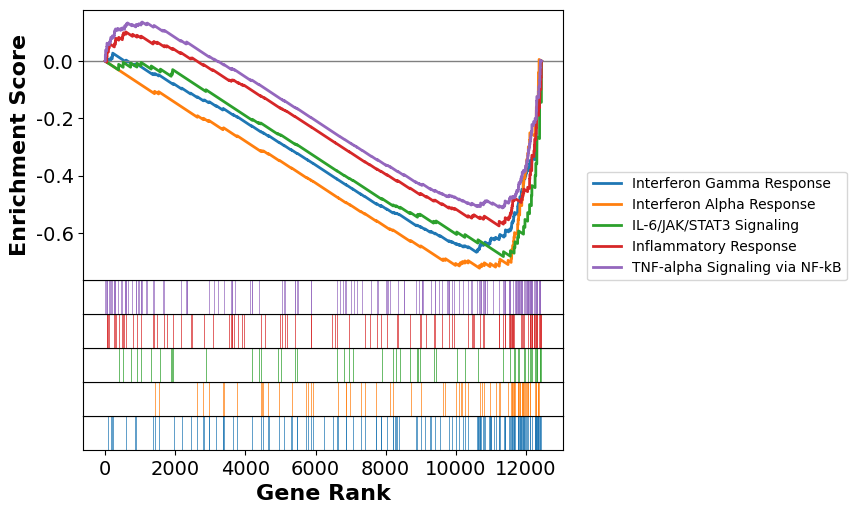

In [155]:
terms = HALLMARK_HGPS_UMK57.res2d.Term
axs = HALLMARK_HGPS_UMK57.plot(terms[[2, 3, 5, 6, 9]], show_ranking=False, legend_kws={'loc': (1.05, 0)})

In [156]:
df_HALLMARK_HGPS_UMK57.to_csv("output_data/df_HALLMARK_HGPS_UMK57.csv")